# 02 - Denoisers and deterministic samplers

Notebook `01` gave us a trained velocity field, but the steering methods that
follow are easier to describe as changes to a clean-data estimate. For the
linear I-CFM path, these are two views of the same learned prediction: velocity
describes how the current state should move, while
$D_\theta(x_t,t)=x_t+(1-t)v_\theta(x_t,t)$ estimates the clean endpoint
compatible with that state. After deriving this bridge, we reuse the same
initial noise to compare Euler, Heun, and RK4, separating errors in numerical
integration from errors in the learned field.


In [1]:
import sys
from pathlib import Path

NOTES_DIR = Path.cwd()
if not (NOTES_DIR / "toy_notes.py").exists():
    NOTES_DIR = Path("notebooks/toy_data")
sys.path.insert(0, str(NOTES_DIR.resolve()))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from toy_notes import *
from notebook_views import *

SEED = 2026
set_seed(SEED)
device = choose_device()
print("device:", device)


device: cuda


In [2]:
model, losses, _ = load_or_train_model(device=device)


## 1. Why can a velocity prediction be read as a denoiser?

Start with one exact training pair. Along the linear conditional path,

$$x_t=x_{noise}+t(x_{data}-x_{noise}).$$

Its pair-specific velocity is $u=x_{data}-x_{noise}$. Rearranging the path gives

$$x_{data}=x_t+(1-t)u.$$

This first identity is exact because the two endpoints are known while we build
a training example. During generation the network sees only $(x_t,t)$, not
those endpoints. Mean-squared-error training therefore learns the conditional
average

$$v^*(x_t,t)=\mathbb E[u\mid x_t,t].$$

Substituting that average into the exact identity gives

$$D^*(x_t,t)=x_t+(1-t)v^*(x_t,t)
=\mathbb E[x_{data}\mid x_t,t].$$

For the trained network we use the same conversion:

$$D_\theta(x_t,t)=x_t+(1-t)v_\theta(x_t,t).$$

The result is the best mean-squared-error clean estimate under the training
pair distribution. It is an average over plausible clean endpoints, not a
guarantee that the model has identified one hidden original. When several modes
are plausible, the average can sit between them; in images, such averaging can
look blurry.

Away from $t=1$, the conversion can also be inverted as
$v_\theta=(D_\theta-x_t)/(1-t)$. Near $t=1$ that division is poorly conditioned,
so code should not use it exactly at the endpoint. This dependence on the
chosen linear path is important: a different path has different conversion
factors.


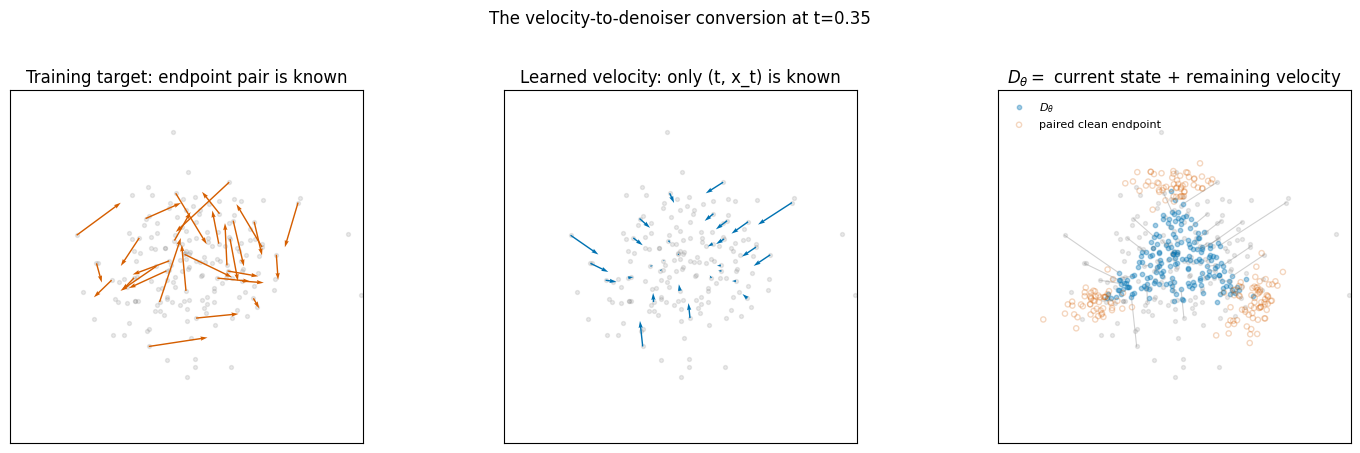

In [3]:
set_seed(SEED + 19)
visual_clean, visual_labels = sample_labeled_mixture(180, device=device)
visual_noise = sample_base(180, device=device)
visual_t_value = 0.35
visual_t = torch.full((180,), visual_t_value, device=device)
visual_xt = forward_noising(visual_clean, visual_t, visual_noise)
pair_velocity = visual_clean - visual_noise
with torch.no_grad():
    learned_velocity = model(visual_t, visual_xt)
    clean_estimate = visual_xt + (1 - visual_t[:, None]) * learned_velocity

plot_velocity_to_denoiser(
    visual_xt, pair_velocity, learned_velocity, clean_estimate, visual_clean,
    t_value=visual_t_value,
)


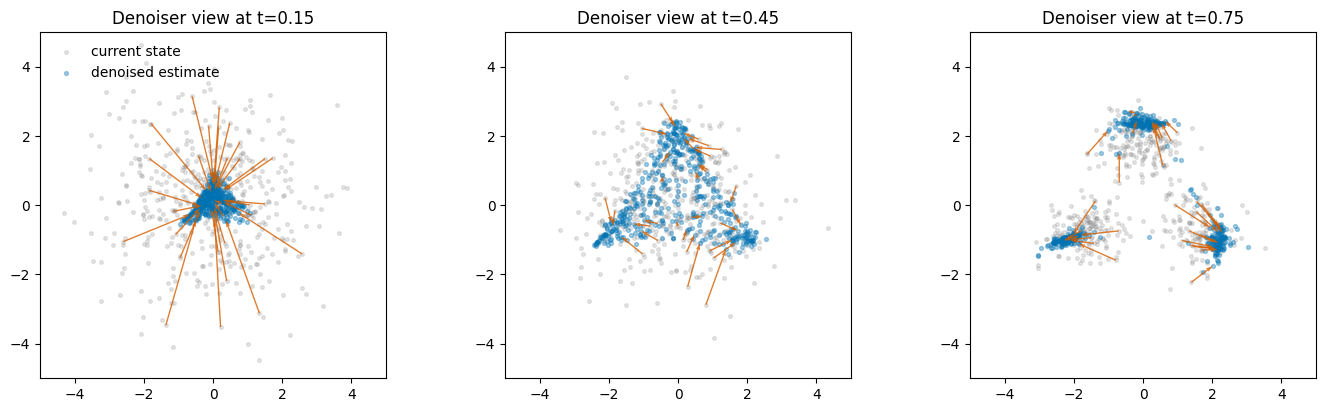

In [4]:
set_seed(SEED + 20)
clean, _ = sample_labeled_mixture(450, device=device)
noise = sample_base(clean.shape[0], device=device)
plot_denoiser_times(model, clean, noise)


## 2. Solver comparison

The model defines the arrows; the solver decides how to follow them. A fair
solver comparison changes only the solver and step count. It keeps the model,
initial noise tensor, and evaluation reference fixed.

Deterministic is conditional on the initial state: repeating the same
`x_noise` repeats the trajectory, while different initial noise points can
still produce a diverse batch of endpoints.

We use a 256-step RK4 trajectory as a numerical reference. This reference does
not remove model error; it only makes solver error small.


In [5]:
def euler_step(velocity, t, x, dt):
    return x + dt * velocity(t, x)

def heun_step(velocity, t, x, dt):
    slope_now = velocity(t, x)
    predicted = x + dt * slope_now
    slope_next = velocity(t + dt, predicted)
    return x + 0.5 * dt * (slope_now + slope_next)

def integrate_with_step(velocity, x0, steps, step_fn):
    x = x0.detach().clone()
    path = [x.cpu()]
    dt = 1.0 / steps
    for index in range(steps):
        t = torch.full((len(x),), index * dt, device=x.device)
        x = step_fn(velocity, t, x, dt).detach()
        path.append(x.cpu())
    return torch.stack(path)


In [6]:
set_seed(SEED + 21)
x0 = sample_base(1200, device=device)
target, _ = sample_labeled_mixture(1200, device=device)

velocity = base_velocity(model)
reference_path = integrate_ode(velocity, x0, steps=256, method="rk4")
paths = {}
for name, step_fn in {"euler": euler_step, "heun": heun_step}.items():
    for steps in [8, 16, 32, 64]:
        paths[(name, steps)] = integrate_with_step(velocity, x0, steps, step_fn)
for steps in [8, 16, 32, 64]:
    paths[("rk4", steps)] = integrate_ode(velocity, x0, steps=steps, method="rk4")

rows, saved_paths = solver_metrics_from_paths(paths, reference_path[-1], target)
solver_table = pd.DataFrame(rows)
display(solver_table.round(4))


,solver,steps,model evaluations,paired endpoint RMSE,Wasserstein distance to target
0,euler,8,8,0.1570,0.3037
1,euler,16,16,0.0862,0.2671
2,euler,32,32,0.0487,0.2592
3,euler,64,64,0.0267,0.2592
4,heun,8,16,0.0266,0.2640
5,heun,16,32,0.0095,0.2627
6,heun,32,64,0.0029,0.2619
7,heun,64,128,0.0008,0.2615
8,rk4,8,32,0.0026,0.2618
9,rk4,16,64,0.0003,0.2614


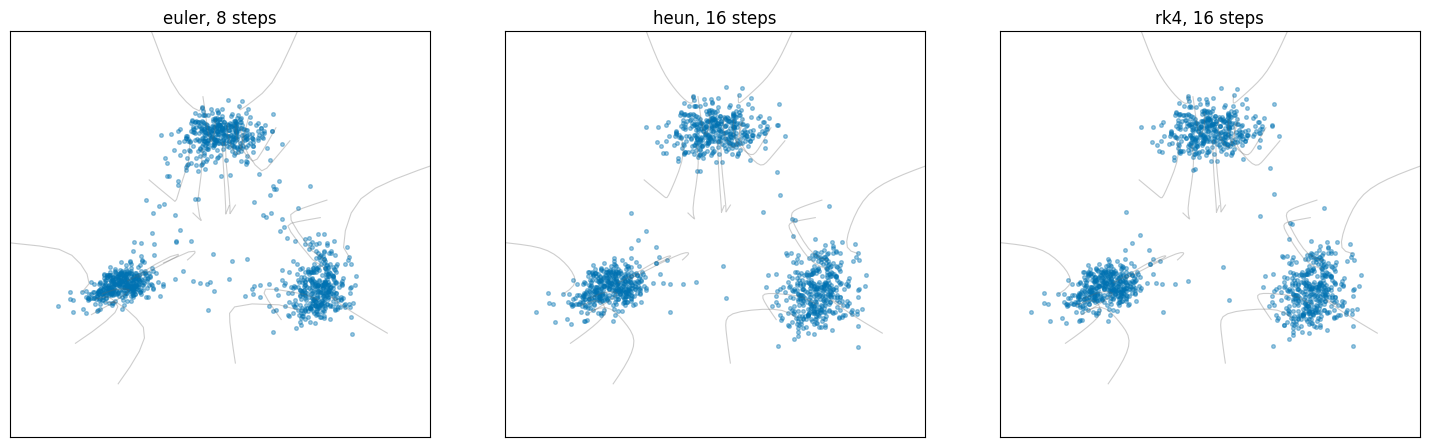

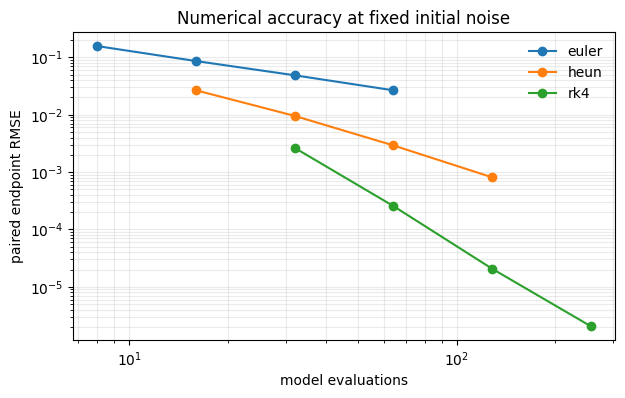

In [7]:
plot_trajectory_comparison(saved_paths, n_lines=22)
plt.show()
plot_solver_accuracy(solver_table)


## 3. Two meanings that must remain separate

**Paired initial noise** is an experimental control. With a deterministic
sampler, the same initial tensor gives sample-by-sample correspondence between
two methods. Endpoint differences can then be attributed to the changed method.

**Noise alignment in NA-RFM** is a steering method. It uses the difference
between a target-class PCA denoiser and a full-data PCA denoiser during the
high-noise window. Notebook `03` implements that mechanism in 2D.

Using the same seed does not implement NA-RFM noise alignment. Conversely, a
noise-alignment experiment should still use paired initial noise for fair
evaluation.

**Questions**

1. Why does RK4 usually need fewer steps but more model evaluations per step?
2. Why is endpoint RMSE meaningful only because every solver starts from the exact same tensor?
3. Does a more accurate ODE solver guarantee a better trained vector field?

A deterministic sampler gives us more than reproducibility: when two methods
start from the same initial noise, their trajectories are paired sample by
sample, so the resulting differences can be attributed to the changed sampling
rule rather than to luck. That pairing is an evaluation tool, not the steering
method called noise alignment. Notebook `03` now uses the denoiser view itself
to construct a class-level correction from two fitted distributions, target
class minus full data, while the trajectory is still highly noisy.
